# Focal Loss를 적용한 감정 분석 모델 훈련

## 🎯 목표
- Original 데이터만 사용하여 훈련
- Focal Loss를 적용하여 클래스 불균형 문제 해결
- 기존 Cross Entropy Loss와 성능 비교

## 📊 Focal Loss의 장점
- **클래스 불균형 해결**: 어려운 샘플에 더 집중
- **어려운 샘플 강조**: 잘못 분류된 샘플에 더 큰 가중치
- **쉬운 샘플 억제**: 너무 쉬운 샘플의 영향력 감소


## Library Import


In [1]:
# Hugging Face Tokenizers 병렬 처리 경고 방지
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# 한국어 텍스트 감정 분석을 위한 필수 라이브러리들
from collections import Counter
import os
import platform
import re
import sys
import warnings

import matplotlib.pyplot as plt
plt.rc("font", family="NanumBarunGothic")

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import koreanize_matplotlib

# 머신러닝 관련 라이브러리
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

import wandb
# 트랜스포머 및 BERT 관련 라이브러리
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    set_seed,
    Trainer,
    TrainingArguments,
)

# PyTorch 데이터 처리
from torch.utils.data import Dataset

# 경고 메시지 필터링
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=UserWarning, module='tqdm')

# 라이브러리 버전 정보 출력
print("=== 라이브러리 버전 정보 ===")
print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"torch: {torch.__version__}")
print(f"transformers: {__import__('transformers').__version__}")
print(f"sklearn: {__import__('sklearn').__version__}")

# GPU 사용 가능 여부 확인
print("\n=== PyTorch GPU 지원 정보 ===")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA 버전: {torch.version.cuda}")
    print(f"GPU 개수: {torch.cuda.device_count()}")
    print(f"현재 GPU: {torch.cuda.current_device()}")
    print(f"GPU 이름: {torch.cuda.get_device_name()}")
else:
    print("CPU에서 실행 중")


/data/ephemeral/repos/boostcamp-movie-review-sentiment-analysis/boostcamp/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/data/ephemeral/repos/boostcamp-movie-review-sentiment-analysis/boostcamp/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model

=== 라이브러리 버전 정보 ===
Python: 3.10.13
Platform: Linux-5.4.0-99-generic-x86_64-with-glibc2.31
pandas: 2.2.3
numpy: 2.2.6
torch: 2.6.0+cu124
transformers: 4.55.0
sklearn: 1.6.1

=== PyTorch GPU 지원 정보 ===
CUDA 사용 가능: True
CUDA 버전: 12.4
GPU 개수: 1
현재 GPU: 0
GPU 이름: Tesla V100-SXM2-32GB


## Random Seed Configuration


In [2]:
# 랜덤 시드 설정
RANDOM_STATE = 42
set_seed(RANDOM_STATE)

print(f"랜덤 시드 {RANDOM_STATE}로 설정 완료")


랜덤 시드 42로 설정 완료


## Data Load


In [3]:
# 데이터 로드
df = pd.read_csv("../../../data/raw/train.csv")

print(f"전체 데이터 크기: {len(df):,}개")
print(f"컬럼: {list(df.columns)}")
print("\n처음 5행:")
df.head()


전체 데이터 크기: 279,650개
컬럼: ['ID', 'review', 'label', 'type']

처음 5행:


,ID,review,label,type
0,0,이 영화는 정말 여성의 강인함과 힘을 제대로 보여주는 작품이었어요! 주인공이 자기 ...,2,augment
1,1,어느 부잣집 도련님의 철없는 행각,1,original
2,3,왜이렇게 재미가없냐 원도 별로였지만 원보다 더 재미없네,0,original
3,4,크리스마스 시즌엔 무조건 홈 알론이죠! 맥컬리 컬킨이 연기한 케빈의 재치있고 천방지...,2,augment
4,5,참나ㅋㅋ이게 무슨 드라마 최초 뮤지컬드라마야 이게무슨ㅋㅋ걍 다른 드라마랑 똑같구만 ...,0,original


## Data Preprocessing


In [4]:
# Original 데이터만 사용 (type == 'original')
df_original = df[df['type'] == 'original'].copy()

print(f"Original 데이터 크기: {len(df_original):,}개")
print(f"전체 대비 비율: {len(df_original)/len(df)*100:.1f}%")

# 라벨 분포 확인
print("\n라벨 분포:")
label_counts = df_original['label'].value_counts().sort_index()
for label, count in label_counts.items():
    print(f"라벨 {label}: {count:,}개 ({count/len(df_original)*100:.1f}%)")

df_original.head()


Original 데이터 크기: 139,825개
전체 대비 비율: 50.0%

라벨 분포:
라벨 0: 57,033개 (40.8%)
라벨 1: 13,608개 (9.7%)
라벨 2: 49,708개 (35.6%)
라벨 3: 19,476개 (13.9%)


,ID,review,label,type
1,1,어느 부잣집 도련님의 철없는 행각,1,original
2,3,왜이렇게 재미가없냐 원도 별로였지만 원보다 더 재미없네,0,original
4,5,참나ㅋㅋ이게 무슨 드라마 최초 뮤지컬드라마야 이게무슨ㅋㅋ걍 다른 드라마랑 똑같구만 ...,0,original
5,6,주인공처럼 군생활하면 맞아죽는다진짜;,0,original
6,8,제발 사라가 satc만한 영화에 출연할 날은 언제일까?,0,original


In [5]:
df_processed = df_original[["ID", "label", "review", "type"]].copy()

print(f"원본 데이터셋 크기: {len(df_processed):,}개")

df_processed.head()

원본 데이터셋 크기: 139,825개


,ID,label,review,type
1,1,1,어느 부잣집 도련님의 철없는 행각,original
2,3,0,왜이렇게 재미가없냐 원도 별로였지만 원보다 더 재미없네,original
4,5,0,참나ㅋㅋ이게 무슨 드라마 최초 뮤지컬드라마야 이게무슨ㅋㅋ걍 다른 드라마랑 똑같구만 ...,original
5,6,0,주인공처럼 군생활하면 맞아죽는다진짜;,original
6,8,0,제발 사라가 satc만한 영화에 출연할 날은 언제일까?,original


In [6]:
print("텍스트 정규화 과정 시작")
print("=" * 50)

# 대소문자 정규화 (BERT가 처리하지만 일관성을 위해)
print("\n1단계: 대소문자 정규화 수행 중...")
df_processed["review_normalized"] = df_processed["review"].str.lower()
print("✓ 소문자 변환 완료")

# 구두점 정규화
print("\n2단계: 구두점 정규화 수행 중...")


def normalize_punctuation(text):
    # NaN 또는 float 타입 체크
    if pd.isna(text) or not isinstance(text, str):
        return text
    
    # 여러 개의 구두점을 하나로 정규화
    text = re.sub(r"[.]{2,}", ".", text)
    text = re.sub(r"[!]{2,}", "!", text)
    text = re.sub(r"[?]{2,}", "?", text)
    text = re.sub(r"[,]{2,}", ",", text)

    # 구두점 주변 공백 정리
    text = re.sub(r"\s+([.,!?])", r"\1", text)
    text = re.sub(r"([.,!?])\s+", r"\1 ", text)

    return text


df_processed["review_normalized"] = df_processed["review_normalized"].apply(
    normalize_punctuation
)
print("✓ 구두점 정규화 완료")

# 특수문자 추가 정리
print("\n3단계: 특수문자 정리 수행 중...")


def clean_special_chars(text):
    # NaN 또는 float 타입 체크
    if pd.isna(text) or not isinstance(text, str):
        return text
    
    # URL 패턴 제거 (있는 경우)
    # URL 패턴 제거 (http/https 및 fragment 포함)
    text = re.sub(
        r"http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+#]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+",
        "",
        text,
    )
    text = re.sub(
        r"www\.[a-zA-Z0-9\-_~:/?#\[\]@!$&'()*+,;=.]+",
        "",
        text,
    )

    # '노려p://'와 같은 케이스에서 p://만 사라지게 하려면 바로 뒤에 오는 p:// 패턴만 지우는 것이 적합합니다.
    # 기존 정규식은 p:// 뒤에 반드시 '.'이 온다고 가정하여 오작동하며, 문자열을 너무 많이 지웁니다.
    # 아래처럼 p://만 삭제하는 쪽이 의도와 부합합니다.
    text = re.sub(r"p://", "", text)

    # 지정된 도메인 리스트 확장에 따라 도메인 패턴 제거
    tlds = [
        'com', 'net', 'org', 'co', 'kr', 'io', 'me', 'info', 'biz', 'tv', 'ai', 'app', 'dev',
        'xyz', 'us', 'uk', 'jp', 'cn', 'ru', 'site', 'store', 'online', 'top', 'tech', 'shop', 'cloud'
    ]
    tld_pattern = "|".join(tlds)
    # 'something.tld' 또는 'something.something.tld' 등, 최소한 도메인 알파벳이 마지막인 경우
    text = re.sub(
        rf"\b[a-zA-Z0-9\-_]+(?:\.[a-zA-Z0-9\-_]+)*\.({tld_pattern})\b",
        "", text)
    


    # 이메일 패턴 제거 (있는 경우)
    text = re.sub(r"\S+@\S+", "", text)

    # sweeti-potato@와 같이 '@'로 끝나는 이메일 fragment 제거
    text = re.sub(r"\b[\w\.\-]+@\b", "", text)
    # 이메일 username@ 처럼 @로 끝나는 형태 - username까지 같이 삭제
    text = re.sub(r"\b[\w\.\-]+@(?=\s|$)", "", text)

    # hsj1549@ 처럼 '@'로 끝나는 멘션 등도 한 번 더 처리
    text = re.sub(r"@\b", "", text)
    text = re.sub(r"\b@\b", "", text)
    text = re.sub(r"\b@\s", " ", text)

    # 멘션 패턴 제거 (있는 경우)
    text = re.sub(r"@\w+", "", text)

    # 과도한 공백 정리
    text = re.sub(r"\s+", " ", text)


    # 『내용』, 【내용】, 《내용》, ｢내용｣ 등 특수 괄호(전각 포함)로 둘러싸인 텍스트 제거 (여러 번 등장 가능하므로 반복적으로 모두 제거)
    # 대표적인 특수 괄호 모음: 『 』 【 】 《 》 「 」 〈 〉 ｢ ｣ “ ” ‘ ’
    # re.DOTALL 옵션으로 줄바꿈 포함 영역 지움, 반복 적용해서 모든 패턴 제거
    special_bracket_pattern = r"[『【《「〈｢“‘](.*?)[』】》」〉｣”’]"
    prev_text = None
    while prev_text != text:
        prev_text = text
        text = re.sub(special_bracket_pattern, "", text, flags=re.DOTALL)

    # 날짜 제거 (YYYY-MM-DD, YYYY/MM/DD, YY.MM.DD, YYYY.MM.DD, YYYY년MM월DD일, MM/DD, MM-DD, MM.DD 등)
    date_patterns = [
        r'\b\d{4}[-/.]\d{1,2}[-/.]\d{1,2}\b',      # 2021-12-30, 2021/12/30, 2021.12.30
        r'\b\d{2}[-/.]\d{1,2}[-/.]\d{1,2}\b',      # 21-12-30, 21.12.30, 21/12/30
        r'\b\d{1,2}[-/.]\d{1,2}\b',                # 12-30, 12.30, 12/30 (월일)
        r'\b\d{4}년\s?\d{1,2}월\s?\d{1,2}일\b',     # 2021년 12월 30일, 2021년12월30일
        r'\b\d{2}년\s?\d{1,2}월\s?\d{1,2}일\b',     # 21년 12월 30일
        r'\b\d{4}년\s?\d{1,2}월\b',                # 2021년 12월 (년월)
        r'\b\d{4}년\b',                            # 2021년
    ]
    for pat in date_patterns:
        text = re.sub(pat, "", text)

    # 전화번호 제거 패턴 추가
    phone_patterns = [
        r'\b01[016789][ -]?\d{3,4}[ -]?\d{4}\b',        # 010-1234-5678, 011 222 3333, 01612345678 등
        r'\b\d{2,4}[ -]?\d{3,4}[ -]?\d{4}\b',           # 02-123-4567, 053 123 4567, 0311234567 등 일반 번호
        r'\b\d{4}[ -]?\d{4}\b',                         # 1234-5678, 12345678 등
    ]
    for pat in phone_patterns:
        text = re.sub(pat, "", text)

    # 금액 패턴 제거
    price_patterns = [
        r'\b\d+원\b',                    # 1000원, 50000원
        r'\b\d+,\d+원\b',               # 1,000원, 50,000원
        r'\b\d+\.\d+원\b',              # 1000.5원
        r'\b\d+만원\b',                 # 1만원, 10만원
        r'\b\d+천원\b',                 # 1천원, 5천원
        r'\b\d+억원\b',                 # 1억원
        r'\$\d+',                       # $100, $50
        r'\b\d+달러\b',                 # 100달러
    ]
    for pat in price_patterns:
        text = re.sub(pat, "", text)

    # 시간 패턴 제거
    time_patterns = [
        r'\b\d{1,2}:\d{2}(?::\d{2})?\b',  # 14:30, 14:30:25
        r'\b\d{1,2}시\s?\d{1,2}분\b',     # 2시 30분, 2시30분
        r'\b\d{1,2}시간\b',               # 2시간, 10시간
        r'\b\d{1,2}분\b',                 # 30분, 5분
        r'\b\d{1,2}초\b',                 # 30초, 5초
        r'\b오전\s?\d{1,2}시\b',          # 오전 9시
        r'\b오후\s?\d{1,2}시\b',          # 오후 2시
    ]  
    for pat in time_patterns:
        text = re.sub(pat, "", text)

    # 영화 관련 패턴 제거
    movie_patterns = [
        r'\b\d+편\b',                    # 1편, 2편, 3편
        r'\b\d+부작\b',                  # 1부작, 2부작
        r'\b\d+기\b',                    # 1기, 2기
        r'\b\d+회차\b',                  # 1회차, 2회차
        r'\b\d+화\b',                    # 1화, 2화
        r'\b\d+분\s?\d+초\b',            # 120분 30초
        r'\b\d+분\b',                    # 120분 (영화 상영시간)
        r'\b\d+등급\b',                  # 15등급, 18등급
        r'\b\d+세\s?이상\b',             # 15세 이상
    ]    
    for pat in movie_patterns:
        text = re.sub(pat, "", text)

    # SNS/플랫폼 패턴 제거
    sns_patterns = [
        r'\b#\w+\b',                     # 해시태그 #영화 #추천
        r'\b@\w+\b',                     # 멘션 @username
        r'\bRT\b',                       # 리트윗 표시
        r'\b좋아요\s?\d+\b',             # 좋아요 100
        r'\b댓글\s?\d+\b',               # 댓글 50
        r'\b공유\s?\d+\b',               # 공유 20
        r'\b조회수\s?\d+\b',             # 조회수 1000
        r'\b구독자\s?\d+\b',             # 구독자 5000
    ]
    for pat in sns_patterns:
        text = re.sub(pat, "", text)

    # 기타 노이즈 패턴 제거
    noise_patterns = [
        r'\b\d+번\b',                    # 1번, 2번
        r'\b\d+개\b',                    # 1개, 2개
        r'\b\d+명\b',                    # 1명, 2명
        r'\b\d+장\b',                    # 1장, 2장
        r'\b\d+회\b',                    # 1회, 2회
        r'\b\d+차\b',                    # 1차, 2차
        r'\b\d+번째\b',                  # 1번째, 2번째
        r'\b\d+위\b',                    # 1위, 2위
        r'\b\d+등\b',                    # 1등, 2등
        r'\b\d+점\b',                    # 1점, 2점
        r'\b\d+점대\b',                  # 1점대, 2점대
        r'\b\d+점만점\b',                # 10점만점
        r'\b\d+점\s?만점\b',             # 10점 만점
    ]
    for pat in noise_patterns:
        text = re.sub(pat, "", text)

    # 특수 문자 및 기호 제거
    special_chars = [
        r'[★☆♥♡♠♣♦]',                  # 특수 기호
        r'[♪♫♬♩]',                      # 음악 기호
        r'[→←↑↓]',                      # 화살표
        r'[①②③④⑤⑥⑦⑧⑨⑩]',            # 원 숫자
        r'[⑴⑵⑶⑷⑸⑹⑺⑻⑼⑽]',            # 괄호 숫자
        r'[❶❷❸❹❺❻❼❽❾❿]',            # 검은 원 숫자
        r'[ⓐⓑⓒⓓⓔⓕⓖⓗⓘⓙ]',            # 원 문자
    ]
    for pat in special_chars:
        text = re.sub(pat, "", text)

    return text.strip()


df_processed["review_normalized"] = df_processed["review_normalized"].apply(
    clean_special_chars
)
print("✓ URL/이메일/멘션 제거 완료")

# 정규화 후 빈 텍스트 처리
print("\n4단계: 정규화 후 빈 텍스트 확인 중...")
empty_after_normalization = df_processed["review_normalized"].str.strip().eq("").sum()
if empty_after_normalization > 0:
    df_processed = df_processed[df_processed["review_normalized"].str.strip() != ""]
    print(f"✓ 빈 텍스트 {empty_after_normalization}개 제거")
else:
    print("✓ 빈 텍스트 없음")

# 정규화 전후 비교
print("\n" + "=" * 50)
print("정규화 결과 요약:")
print(f"최종 데이터 크기: {len(df_processed):,}개")
print(
    f"평균 길이 - 정규화됨: {df_processed['review_normalized'].str.len().mean():.1f}자"
)
print("=" * 50)

텍스트 정규화 과정 시작

1단계: 대소문자 정규화 수행 중...


✓ 소문자 변환 완료

2단계: 구두점 정규화 수행 중...
✓ 구두점 정규화 완료

3단계: 특수문자 정리 수행 중...
✓ URL/이메일/멘션 제거 완료

4단계: 정규화 후 빈 텍스트 확인 중...
✓ 빈 텍스트 135개 제거

정규화 결과 요약:
최종 데이터 크기: 139,690개
평균 길이 - 정규화됨: 34.3자


In [7]:
# 기본 텍스트 정리 함수
def clean_text(text):
    """
    한국어 텍스트를 위한 기본 텍스트 정리 함수

    전처리 단계:
    1. 불완전한 한글 제거 (자음/모음만 있는 경우)
    2. 반복되는 감정 표현 정규화 (ㅋㅋㅋ, ㅠㅠㅠ 등)
    3. 과도한 문자 반복 축소 (4번 이상 → 3번으로)
    4. 특수문자 제거 (한글, 숫자, 기본 구두점, 감정표현 제외)
    5. 공백 정규화
    """
    if pd.isna(text):
        return ""

    text = str(text).strip()

    # 한국어 특화 전처리
    text = re.sub(
        r"[ㄱ-ㅎㅏ-ㅣ]+", "", text
    )  # 불완전한 한글 제거 (자음/모음만 있는 경우)
    text = re.sub(r"([ㅋㅎ])\1{2,}", r"\1\1", text)  # 웃음 표현 정규화: ㅋㅋㅋ+ → ㅋㅋ
    text = re.sub(
        r"([ㅠㅜㅡ])\1{2,}", r"\1\1", text
    )  # 슬픔 표현 정규화: ㅠㅠㅠ+ → ㅠㅠ
    text = re.sub(
        r"(.)\1{3,}", r"\1\1\1", text
    )  # 과도한 반복 축소: 4번 이상 반복 → 3번으로
    text = re.sub(r"[^\w\s가-힣.,!?ㅋㅎㅠㅜㅡ~\-]", " ", text)  # 필요한 문자만 유지
    text = re.sub(r"\s+", " ", text)  # 다중 공백을 단일 공백으로

    return text.strip()


print("텍스트 전처리 과정 시작")
print("=" * 50)
initial_size = len(df_processed)
print(f"초기 데이터 크기: {initial_size:,}개")

# 1단계: 텍스트 정리 적용
print("\n1단계: 기본 텍스트 정리 수행 중...")
df_processed["review_cleaned"] = df_processed["review_normalized"].apply(clean_text)
print("✓ 한글 자음/모음 정리, 반복 표현 정규화, 특수문자 제거 완료")

# 2단계: 빈 텍스트 제거
print("\n2단계: 빈 텍스트 제거 중...")
empty_count = df_processed["review_cleaned"].str.strip().eq("").sum()
if empty_count > 0:
    df_processed = df_processed[df_processed["review_cleaned"].str.strip() != ""]
    print(f"✓ 빈 텍스트 {empty_count}개 제거")
else:
    print("✓ 빈 텍스트 없음")

# 3단계: 중복 제거
print("\n3단계: 중복 데이터 제거 중...")
duplicates_count = df_processed.duplicated(subset=["review_cleaned", "label"]).sum()
if duplicates_count > 0:
    df_processed = df_processed.drop_duplicates(subset=["review_cleaned", "label"])
    print(f"✓ 중복 데이터 {duplicates_count}개 제거")
else:
    print("✓ 중복 데이터 없음")

# 최종 결과 요약
final_size = len(df_processed)
removed = initial_size - final_size
print("\n" + "=" * 50)
print("전처리 결과 요약:")
print(f"최종 데이터 크기: {initial_size:,} → {final_size:,}")
print(f"제거된 데이터: {removed:,}개 ({removed / initial_size * 100:.1f}%)")
print("=" * 50)

텍스트 전처리 과정 시작
초기 데이터 크기: 139,690개

1단계: 기본 텍스트 정리 수행 중...
✓ 한글 자음/모음 정리, 반복 표현 정규화, 특수문자 제거 완료

2단계: 빈 텍스트 제거 중...
✓ 빈 텍스트 345개 제거

3단계: 중복 데이터 제거 중...
✓ 중복 데이터 3891개 제거

전처리 결과 요약:
최종 데이터 크기: 139,690 → 135,454
제거된 데이터: 4,236개 (3.0%)


## Focal Loss 구현


In [8]:
class FocalLoss(nn.Module):
    """
    Focal Loss 구현
    
    Focal Loss는 클래스 불균형 문제를 해결하기 위해 제안된 손실 함수입니다.
    어려운 샘플(잘못 분류된 샘플)에 더 큰 가중치를 부여하고,
    쉬운 샘플(올바르게 분류된 샘플)의 가중치는 줄입니다.
    
    Args:
        alpha (float): 클래스 가중치 (기본값: 1.0)
        gamma (float): focusing parameter (기본값: 2.0)
        reduction (str): 손실 감소 방식 ('mean', 'sum', 'none')
    """
    
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        """
        Focal Loss 계산
        
        Args:
            inputs: 모델의 로짓 출력 (batch_size, num_classes)
            targets: 실제 라벨 (batch_size,)
        
        Returns:
            focal_loss: 계산된 Focal Loss
        """
        # Cross Entropy Loss 계산
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        
        # 확률 계산 (소프트맥스 적용)
        pt = torch.exp(-ce_loss)
        
        # Focal Loss 계산
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Focal Loss 테스트
print("=== Focal Loss 테스트 ===")
focal_loss = FocalLoss(alpha=1.0, gamma=0.5)

# 테스트 데이터 생성
batch_size, num_classes = 4, 4
inputs = torch.randn(batch_size, num_classes)
targets = torch.randint(0, num_classes, (batch_size,))

# Cross Entropy Loss와 비교
ce_loss = F.cross_entropy(inputs, targets)
focal_loss_value = focal_loss(inputs, targets)

print(f"Cross Entropy Loss: {ce_loss.item():.4f}")
print(f"Focal Loss: {focal_loss_value.item():.4f}")
print("Focal Loss 구현 완료!")


=== Focal Loss 테스트 ===
Cross Entropy Loss: 3.2316
Focal Loss: 3.1560
Focal Loss 구현 완료!


## Custom Trainer with Focal Loss


In [9]:
class FocalLossTrainer(Trainer):
    """
    Focal Loss를 사용하는 커스텀 Trainer
    """
    
    def __init__(self, focal_loss_alpha=1.0, focal_loss_gamma=0.5, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.focal_loss = FocalLoss(alpha=focal_loss_alpha, gamma=focal_loss_gamma)
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """
        Focal Loss를 사용하여 손실 계산
        (Trainer 내부 호출: 추가 인자 허용)
        """
        labels = inputs.get("labels")
        
        # 모델 출력
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # Focal Loss 계산
        loss = self.focal_loss(logits, labels)
        
        return (loss, outputs) if return_outputs else loss

print("FocalLossTrainer 클래스 정의 완료!")


FocalLossTrainer 클래스 정의 완료!


## Dataset Class


In [10]:
class ReviewDataset(Dataset):
    """
    리뷰 데이터를 위한 PyTorch Dataset 클래스
    
    이 클래스는 텍스트 데이터를 BERT 모델이 처리할 수 있는 형태로 변환합니다.
    
    Attributes:
        texts: 리뷰 텍스트 리스트
        labels: 감정 라벨 리스트
        tokenizer: BERT 토크나이저
        max_length: 최대 시퀀스 길이
    """
    
    def __init__(self, texts, labels, tokenizer, max_length=128):
        """
        ReviewDataset 초기화
        
        Args:
            texts: 리뷰 텍스트 리스트 또는 pandas Series
            labels: 감정 라벨 리스트 또는 pandas Series
            tokenizer: BERT 토크나이저
            max_length: 최대 시퀀스 길이 (기본값: 128)
        """
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        """
        데이터셋 크기 반환
        """
        return len(self.texts)
    
    def __getitem__(self, idx):
        """
        특정 인덱스의 데이터 아이템 반환
        
        Args:
            idx: 데이터 인덱스
        
        Returns:
            dict: 토크나이징된 텍스트와 라벨을 포함한 딕셔너리
        """
        # 텍스트 토크나이징 및 패딩
        encoding = self.tokenizer(
            str(self.texts.iloc[idx]) if hasattr(self.texts, 'iloc') else str(self.texts[idx]),
            truncation=True,  # 최대 길이 초과시 자르기
            padding="max_length",  # 최대 길이까지 패딩
            max_length=self.max_length,
            return_tensors="pt",  # PyTorch 텐서로 반환
        )
        
        # 기본 아이템 구성 (input_ids, attention_mask)
        item = {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
        }
        
        # 라벨 추가 (훈련용)
        if self.labels is not None:
            label = self.labels.iloc[idx] if hasattr(self.labels, 'iloc') else self.labels[idx]
            item["labels"] = torch.tensor(label, dtype=torch.long)
        
        return item

print("ReviewDataset 클래스 정의 완료!")


ReviewDataset 클래스 정의 완료!


## Data Split


In [11]:
# 훈련/검증 데이터 분할
train_data, val_data = train_test_split(
    df_processed,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_processed['label']  # 라벨 비율 유지
)

print(f"훈련 데이터: {len(train_data):,}개")
print(f"검증 데이터: {len(val_data):,}개")

# 라벨 분포 확인
print("\\n훈련 데이터 라벨 분포:")
train_label_counts = train_data['label'].value_counts().sort_index()
for label, count in train_label_counts.items():
    print(f"라벨 {label}: {count:,}개 ({count/len(train_data)*100:.1f}%)")

print("\\n검증 데이터 라벨 분포:")
val_label_counts = val_data['label'].value_counts().sort_index()
for label, count in val_label_counts.items():
    print(f"라벨 {label}: {count:,}개 ({count/len(val_data)*100:.1f}%)")


훈련 데이터: 108,363개
검증 데이터: 27,091개
\n훈련 데이터 라벨 분포:
라벨 0: 44,366개 (40.9%)
라벨 1: 10,597개 (9.8%)
라벨 2: 38,226개 (35.3%)
라벨 3: 15,174개 (14.0%)
\n검증 데이터 라벨 분포:
라벨 0: 11,092개 (40.9%)
라벨 1: 2,649개 (9.8%)
라벨 2: 9,556개 (35.3%)
라벨 3: 3,794개 (14.0%)


## Model and Tokenizer Setup


In [12]:
# 모델 및 토크나이저 설정
model_name = "beomi/kcbert-base"
print(f"🤖 모델 로딩: {model_name}")

# KLUE-BERT 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 시퀀스 분류를 위한 BERT 모델 로드 (4개 클래스 분류)
NUM_CLASSES = 4
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=NUM_CLASSES,
    hidden_dropout_prob=0.2,
    attention_probs_dropout_prob=0.2,
)

print(f"토크나이저 로드 완료: {tokenizer.__class__.__name__}")
print(f"모델 로드 완료: {model.__class__.__name__}")
print(f"분류 클래스 수: {NUM_CLASSES}")
print(f"모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")


🤖 모델 로딩: beomi/kcbert-base


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at beomi/kcbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


토크나이저 로드 완료: BertTokenizerFast
모델 로드 완료: BertForSequenceClassification
분류 클래스 수: 4
모델 파라미터 수: 108,921,604


## Dataset Creation


In [13]:
# 데이터셋 생성
train_dataset = ReviewDataset(
    train_data["review_cleaned"],
    train_data["label"],
    tokenizer,
    max_length=128
)

val_dataset = ReviewDataset(
    val_data["review_cleaned"],
    val_data["label"],
    tokenizer,
    max_length=128
)

print(f"훈련 데이터셋 크기: {len(train_dataset):,}")
print(f"검증 데이터셋 크기: {len(val_dataset):,}")

# 데이터셋 샘플 확인
sample = train_dataset[0]
print(f"\\n데이터셋 샘플:")
print(f"input_ids shape: {sample['input_ids'].shape}")
print(f"attention_mask shape: {sample['attention_mask'].shape}")
print(f"label: {sample['labels'].item()}")


훈련 데이터셋 크기: 108,363
검증 데이터셋 크기: 27,091
\n데이터셋 샘플:
input_ids shape: torch.Size([128])
attention_mask shape: torch.Size([128])
label: 3


## Evaluation Metrics


In [14]:
def compute_metrics(eval_pred):
    """
    평가 지표 계산 함수
    
    Args:
        eval_pred: (predictions, labels) 튜플
    
    Returns:
        dict: 계산된 평가 지표들
    """
    predictions, labels = eval_pred
    
    # 예측값을 클래스 인덱스로 변환
    predictions = np.argmax(predictions, axis=1)
    
    # 정확도 계산
    accuracy = accuracy_score(labels, predictions)
    
    # F1 점수 계산 (macro average)
    f1 = f1_score(labels, predictions, average='macro')
    
    return {
        'accuracy': accuracy,
        'f1': f1
    }

print("평가 지표 함수 정의 완료!")


평가 지표 함수 정의 완료!


In [24]:
from transformers import TrainerCallback

class ReduceLROnPlateauCallback(TrainerCallback):
    def __init__(self, factor=0.5, patience=2, min_lr=1e-7):
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.best_metric = None
        self.num_bad_epochs = 0

    def on_evaluate(self, args, state, control, metrics, **kwargs):
        current_metric = metrics.get("eval_loss")
        optimizer = kwargs["model"].optimizer
        if current_metric is None or optimizer is None:
            return control

        if self.best_metric is None or current_metric < self.best_metric:
            self.best_metric = current_metric
            self.num_bad_epochs = 0
        else:
            self.num_bad_epochs += 1

        if self.num_bad_epochs >= self.patience:
            for group in optimizer.param_groups:
                old_lr = group["lr"]
                new_lr = max(old_lr * self.factor, self.min_lr)
                group["lr"] = new_lr
                print(f"🔽 Reduce LR: {old_lr:.6f} → {new_lr:.6f}")
            self.num_bad_epochs = 0
        return control


## Training Configuration


In [15]:
# 훈련 설정
BATCH_SIZE = 64
LEARNING_RATE = 1e-5
NUM_EPOCHS = 5  # ex) 학습량을 늘리기 위해 에포크 수를 5로 증가
SAVE_MODEL = True
WEIGHT_DECAY = 0.1

# Focal Loss 하이퍼파라미터
FOCAL_ALPHA = 2.0  # 클래스 가중치
FOCAL_GAMMA = 1.5  # focusing parameter

MAX_GRAD_NORM = 1.0
WARMUP_STEPS = 1000

print(f"=== 훈련 설정 ===")
print(f"배치 크기: {BATCH_SIZE}")
print(f"학습률: {LEARNING_RATE}")
print(f"에포크 수: {NUM_EPOCHS}")
print(f"Focal Loss Alpha: {FOCAL_ALPHA}")
print(f"Focal Loss Gamma: {FOCAL_GAMMA}")
print(f"모델 저장: {SAVE_MODEL}")


=== 훈련 설정 ===
배치 크기: 64
학습률: 1e-05
에포크 수: 5
Focal Loss Alpha: 2.0
Focal Loss Gamma: 1.5
모델 저장: True


In [16]:
# Wandb 프로젝트 초기화
wandb.init(
    project="focal-loss-sentiment-analysis",  # 프로젝트 이름
    name=f"focal_loss_alpha{FOCAL_ALPHA}_gamma{FOCAL_GAMMA}",  # 실험 이름
    config={
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "epochs": NUM_EPOCHS,
        "focal_alpha": FOCAL_ALPHA,
        "focal_gamma": FOCAL_GAMMA,
        "model_name": model_name,
        "max_grad_norm": 1.0,
        "weight_decay": 0.01,
    }
)

wandb: Currently logged in as: pileuszu (pileuszu16) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
# TrainingArguments 설정
training_args = TrainingArguments(
    output_dir="./focal_loss_results",
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    warmup_steps=WARMUP_STEPS,
    weight_decay=WEIGHT_DECAY,
    learning_rate=LEARNING_RATE,
    logging_dir="./logs",
    logging_steps=500,
    eval_strategy="steps",
    eval_steps=500,
    save_strategy="epoch" if SAVE_MODEL else "no",
    load_best_model_at_end=False,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    save_total_limit=2 if SAVE_MODEL else 0,
    seed=RANDOM_STATE,
    fp16=True,  # 혼합 정밀도 훈련
    dataloader_num_workers=4,
    remove_unused_columns=False,
    max_grad_norm=MAX_GRAD_NORM,
    report_to="wandb",
    run_name=f"focal_loss_alpha{FOCAL_ALPHA}_gamma{FOCAL_GAMMA}",
    lr_scheduler_type="cosine_with_restarts",
    num_cycles=NUM_EPOCHS,
    warmup_ratio=0.1,
    optim="adamw_torch",
)

print("TrainingArguments 설정 완료!")


TrainingArguments 설정 완료!


## Model Training with Focal Loss


In [ ]:
# 수정된 코드 (Early Stopping 추가)
from transformers import EarlyStoppingCallback

# Early Stopping 콜백 생성
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=5,  # 2 에포크 동안 개선 없으면 중단
    early_stopping_threshold=0.001  # 최소 개선 임계값
)

# Focal Loss를 사용하는 Trainer 초기화
trainer_focal = FocalLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    focal_loss_alpha=FOCAL_ALPHA,
    focal_loss_gamma=FOCAL_GAMMA,
    callbacks=[ReduceLROnPlateauCallback(factor=0.5, patience=2), EarlyStoppingCallback(early_stopping_patience=10)]
)

print("Focal Loss Trainer 초기화 완료!")
print(f"훈련 샘플: {len(train_dataset):,}개")
print(f"검증 샘플: {len(val_dataset):,}개")


Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Focal Loss Trainer 초기화 완료!
훈련 샘플: 108,363개
검증 샘플: 27,091개


In [ ]:
# 훈련 시작
print("=" * 50)
print("Focal Loss 모델 훈련 시작")
print("=" * 50)

trainer.train(resume_from_checkpoint=True)
trainer_focal.train()

print("\\n훈련 완료!")


Focal Loss 모델 훈련 시작


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.686700,0.628491,0.771363,0.694167
2,0.629600,0.591343,0.786793,0.704005
3,0.533800,0.579106,0.793252,0.712329
4,0.444600,0.579673,0.797017,0.723070
5,0.431600,0.582578,0.797350,0.723745


\n훈련 완료!


## Model Evaluation


In [20]:
# 최종 평가
print("=" * 50)
print("Focal Loss 모델 최종 평가")
print("=" * 50)

eval_results = trainer_focal.evaluate()

print("\\n최종 성능 결과:")
print("=" * 40)
print(f"정확도 (Accuracy): {eval_results['eval_accuracy']:.4f}")
print(f"F1-Score: {eval_results['eval_f1']:.4f}")
print(f"검증 손실 (Loss): {eval_results['eval_loss']:.4f}")
print("=" * 40)


Focal Loss 모델 최종 평가


\n최종 성능 결과:
정확도 (Accuracy): 0.7973
F1-Score: 0.7237
검증 손실 (Loss): 0.5826


## Confusion Matrix Analysis


Focal Loss 모델 혼동 행렬:


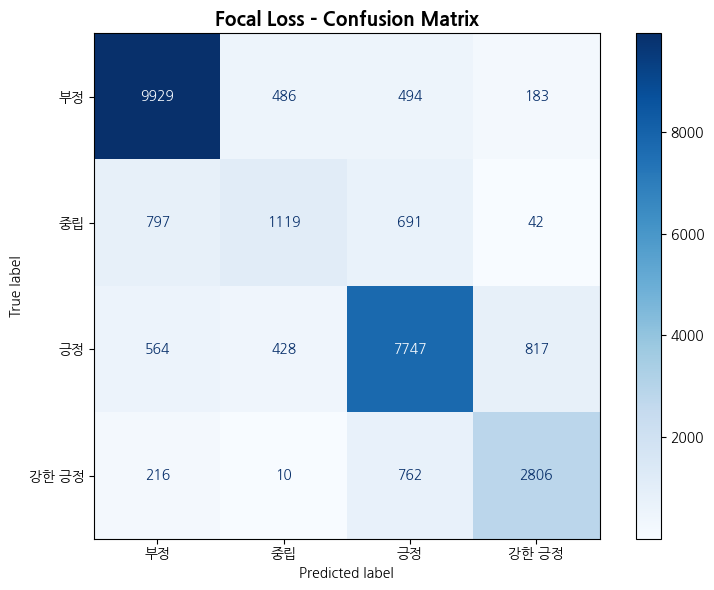

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(trainer, dataset, target_names, title="Confusion Matrix"):
    """혼동 행렬 시각화"""
    preds_output = trainer.predict(dataset)
    y_true = preds_output.label_ids
    y_pred = np.argmax(preds_output.predictions, axis=1)
    
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 클래스 이름
class_names = ["부정", "중립", "긍정", "강한 긍정"] 

# Focal Loss 모델 혼동 행렬
print("Focal Loss 모델 혼동 행렬:")
plot_confusion_matrix(trainer_focal, val_dataset, class_names, "Focal Loss - Confusion Matrix")


## Class-wise Performance Analysis


In [22]:
def analyze_class_performance(trainer, dataset, model_name):
    """클래스별 성능 분석"""
    preds_output = trainer.predict(dataset)
    y_true = preds_output.label_ids
    y_pred = np.argmax(preds_output.predictions, axis=1)
    
    # 분류 리포트 생성
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    
    print(f"\\n=== {model_name} 클래스별 성능 ===")
    
    # 클래스별 성능 출력
    for class_name in class_names:
        if class_name in report:
            precision = report[class_name]['precision']
            recall = report[class_name]['recall']
            f1 = report[class_name]['f1-score']
            support = report[class_name]['support']
            
            print(f"{class_name}:")
            print(f"  정밀도: {precision:.4f}")
            print(f"  재현율: {recall:.4f}")
            print(f"  F1점수: {f1:.4f}")
            print(f"  샘플수: {support}")
            print()
    
    return report

# 각 모델별 클래스 성능 분석
focal_report = analyze_class_performance(trainer_focal, val_dataset, "Focal Loss")


\n=== Focal Loss 클래스별 성능 ===
부정:
  정밀도: 0.8629
  재현율: 0.8951
  F1점수: 0.8788
  샘플수: 11092.0

중립:
  정밀도: 0.5477
  재현율: 0.4224
  F1점수: 0.4770
  샘플수: 2649.0

긍정:
  정밀도: 0.7992
  재현율: 0.8107
  F1점수: 0.8049
  샘플수: 9556.0

강한 긍정:
  정밀도: 0.7292
  재현율: 0.7396
  F1점수: 0.7344
  샘플수: 3794.0



## Model Saving


In [23]:
# 모델 저장
if SAVE_MODEL:
    import os
    
    # Focal Loss 모델 저장
    focal_model_path = "../../../model/focal_loss/focal_loss_model"
    try:
        print(f"Focal Loss 모델 저장 중: {focal_model_path}")
        trainer_focal.save_model(focal_model_path)
        tokenizer.save_pretrained(focal_model_path)
        print(f"Focal Loss 모델 저장 완료: {focal_model_path}")
        
        # 저장된 파일 확인
        if os.path.exists(focal_model_path):
            saved_files = os.listdir(focal_model_path)
            print(f"저장된 파일들: {saved_files}")
            
    except Exception as e:
        print(f"Focal Loss 모델 저장 실패: {str(e)}")
        
else:
    print("모델 저장이 비활성화되어 있습니다.")

print("\\n모델 훈련 및 평가 완료!")


Focal Loss 모델 저장 중: ../../../model/focal_loss/focal_loss_model
Focal Loss 모델 저장 완료: ../../../model/focal_loss/focal_loss_model
저장된 파일들: ['model.safetensors', 'tokenizer.json', 'config.json', 'tokenizer_config.json', 'training_args.bin', 'special_tokens_map.json', 'vocab.txt']
\n모델 훈련 및 평가 완료!
